# MLPR LAB 13
### PROSHITA AGARWAL

STEP 1: Import Libraries


In [1]:
# Import numpy for numerical operations
import numpy as np

# Import tensorflow keras for building CNN model
from tensorflow import keras

# Import layers (Conv2D, MaxPooling, Dense, Flatten)
from tensorflow.keras import layers

# Import matplotlib for plotting images
import matplotlib.pyplot as plt

# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

STEP 2: Load MNIST Dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


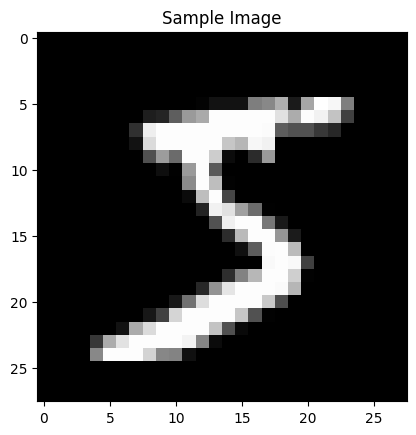

Label of first image: 5


In [2]:
# Load MNIST dataset from keras

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Display shapes of dataset
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# Display first image
plt.imshow(x_train[0], cmap='gray')
plt.title("Sample Image")
plt.show()

# Display corresponding label
print("Label of first image:", y_train[0])

The MNIST dataset was successfully loaded using keras. It consists of handwritten digit images ranging from 0 to 9. The dataset is divided into training and testing sets. The training set contains 60,000 images and the testing set contains 10,000 images. Each image is of size 28×28 pixels.

A sample image was displayed along with its corresponding label. This helps in understanding how the input data looks and what the model is expected to predict.

STEP 3: Preprocess Data (Normalize + Reshape)

In [3]:
# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape data to include channel dimension (required for CNN)
# From (28,28) → (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Display new shapes
print("Training data shape after reshape:", x_train.shape)
print("Testing data shape after reshape:", x_test.shape)

Training data shape after reshape: (60000, 28, 28, 1)
Testing data shape after reshape: (10000, 28, 28, 1)


The MNIST image data was preprocessed by normalizing pixel values from the range 0–255 to 0–1. This helps improve the training performance and stability of the neural network.

The data was then reshaped to include a channel dimension, converting each image from 28×28 to 28×28×1. This is required because CNN models expect input data to have a channel dimension, even for grayscale images.

The updated shapes confirm that the dataset is now in the correct format for training a convolutional neural network.

STEP 4: Build CNN Model

In [4]:
# Create a Sequential CNN model
model = keras.Sequential()

# First Convolutional Layer (Feature Extraction)
model.add(layers.Conv2D(
    filters=32,              # number of kernels
    kernel_size=(3,3),       # size of each kernel
    activation='relu',
    input_shape=(28,28,1)    # input image shape
))

# Pooling Layer (reduces size)
model.add(layers.MaxPooling2D(pool_size=(2,2)))

# Flatten layer (convert 2D → 1D)
model.add(layers.Flatten())

# Dense layer (classification)
model.add(layers.Dense(128, activation='relu'))

# Output layer (10 digits → 0 to 9)
model.add(layers.Dense(10, activation='softmax'))

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

A Convolutional Neural Network (CNN) model was created using a Sequential architecture. The model begins with a convolutional layer that extracts important features from the input images using 32 kernels of size 3×3 with ReLU activation.

A max pooling layer was added to reduce the spatial dimensions of the feature maps and to retain important features. The flattened layer converts the 2D feature maps into a 1D vector, which is then passed through a dense layer for classification.

Finally, an output layer with 10 neurons and softmax activation was used to classify the images into 10 digit classes (0–9). The model summary provides details about each layer and its output shape.

STEP 5: Compile the Model

In [5]:
# Compile the CNN model

model.compile(
    optimizer='adam',                 # optimizer to update weights
    loss='sparse_categorical_crossentropy',  # loss for multi-class classification
    metrics=['accuracy']              # performance metric
)

The CNN model was compiled by specifying the optimizer, loss function, and evaluation metric. The Adam optimizer was used to efficiently update the model weights during training. The loss function chosen was sparse categorical crossentropy, which is suitable for multi-class classification problems where the target labels are integers. Accuracy was used as the evaluation metric to measure the performance of the model.

STEP 6: Train the Model

In [6]:
# Train the CNN model

history = model.fit(
    x_train,
    y_train,
    epochs=5,          # number of times model sees full dataset
    batch_size=64,     # number of samples processed at once
    validation_split=0.1  # 10% of training data used for validation
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.9447 - loss: 0.1888 - val_accuracy: 0.9827 - val_loss: 0.0621
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9817 - loss: 0.0615 - val_accuracy: 0.9837 - val_loss: 0.0578
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9879 - loss: 0.0396 - val_accuracy: 0.9868 - val_loss: 0.0501
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9908 - loss: 0.0297 - val_accuracy: 0.9882 - val_loss: 0.0436
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9942 - loss: 0.0201 - val_accuracy: 0.9878 - val_loss: 0.0450


The CNN model was trained on the MNIST dataset using the training data. The model was trained for 5 epochs, meaning it processed the entire dataset five times. A batch size of 64 was used, which determines how many samples are processed before updating the model weights.

A validation split of 10% was used to monitor the model’s performance on unseen data during training. The training process shows how the loss decreases and accuracy increases over epochs, indicating that the model is learning effectively.

STEP 7: Evaluate the Model (Accuracy + Loss)

In [7]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9856 - loss: 0.0437
Test Loss: 0.043703965842723846
Test Accuracy: 0.9855999946594238


The trained CNN model was evaluated on the test dataset to measure its performance on unseen data. The evaluation returned the loss value and accuracy score. The loss indicates how well the model’s predictions match the true labels, while the accuracy represents the percentage of correctly classified images.

A high accuracy and low loss indicate that the model has learned effectively and generalizes well to new data.

STEP 8: Confusion Matrix and Classification Report

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Confusion Matrix:
 [[ 971    0    4    0    0    1    2    1    1    0]
 [   0 1130    3    0    0    0    0    1    1    0]
 [   0    2 1018    0    1    0    1    9    1    0]
 [   0    0    6  991    0    9    0    3    1    0]
 [   0    1    1    0  972    0    0    0    1    7]
 [   1    0    1    3    0  885    2    0    0    0]
 [   5    2    3    0    1    3  943    0    1    0]
 [   0    2    6    1    0    0    0 1018    1    0]
 [   5    1   10    0    0    4    1    2  948    3]
 [   0    5    0    3    6    4    0    7    4  980]]


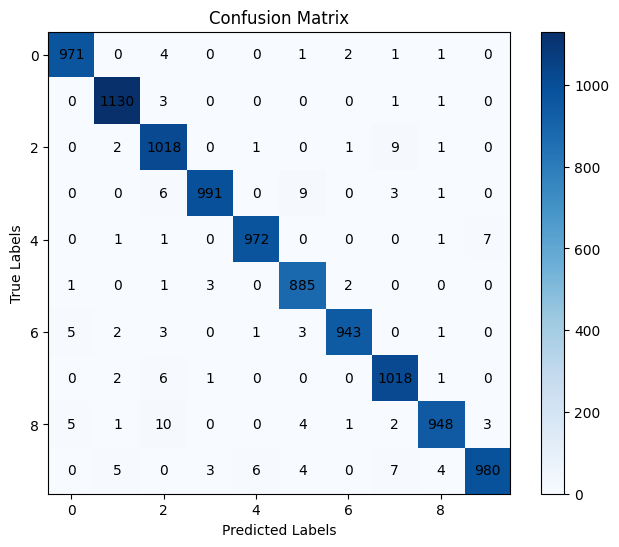


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.97      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [8]:
# Predict labels for test data
y_pred = model.predict(x_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(8,6))

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.colorbar()

# Add numbers inside matrix
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

Predictions were generated for the test dataset using the trained CNN model. The predicted probabilities were converted into class labels using the argmax function. A confusion matrix was created to visualize the number of correct and incorrect predictions for each digit class.

The confusion matrix shows that most predictions lie along the diagonal, indicating correct classifications. A classification report was also generated, providing precision, recall, and F1-score for each class. These metrics help in understanding the model’s performance in detail across all digit categories.

## REPORT

**a) How many layers in the deep neural network were used for feature extraction and how many for feature classification?**

In the CNN model, the feature extraction part consists of the convolutional layer and the pooling layer, which together extract important patterns such as edges and shapes from the input images. The feature classification part consists of the flatten layer and the dense layers, which use the extracted features to classify the images into different digit classes. In this model, one convolutional layer and one pooling layer were used for feature extraction, while one flatten layer and two dense layers were used for classification.

**b) How many kernels were used to extract features on the MNIST images in the first convolutional layer? What were the size of these kernels?**

In the first convolutional layer, 32 kernels (filters) were used to extract features from the MNIST images. Each kernel had a size of 3×3, meaning it scans small 3×3 regions of the image to detect patterns such as edges, curves, and textures. These kernels help the model learn different types of features present in handwritten digits.

**c) What kind of pooling was done on the data and why?**

Max pooling was used in the model. Max pooling reduces the spatial dimensions of the feature maps by selecting the maximum value from each region. This helps in reducing computational complexity, removing noise, and retaining the most important features. It also helps the model become more robust to small variations in the input images.

**d) What were the dimensions of the feature set for each layer of the deep CNN? Why were the dimensions reducing in each layer?**

Initially, the input images had dimensions 28×28×1. After the convolutional layer, the dimensions became smaller due to the application of kernels (for example, around 26×26×32 depending on padding). After the pooling layer, the dimensions were further reduced (for example, around 13×13×32). The flatten layer then converted this into a one-dimensional vector before passing it to the dense layers.

The dimensions reduce in each layer to decrease computational complexity, improve efficiency, and focus on the most important features. This gradual reduction helps the model learn hierarchical representations of the data.

**e) How are the outputs of CNN (which are numbers) i.e. activation outputs of the last layer converted to probabilities and 10 classes (for the 10 digits)?**

The output of the final dense layer is passed through a softmax activation function, which converts the raw output values into probabilities. The softmax function ensures that all output values are between 0 and 1 and that their sum equals 1. Each output node corresponds to one digit class (0–9), and the class with the highest probability is selected as the predicted digit.